# Data Mining: Homework assignment (part 2)

### Theofanis Barmparosos: sdi2200107

### Georgios Spyrou: sdi2200168

Dependencies

In [ ]:
!pip install seaborn
!pip install datasets
!pip install matplotlib
!pip install vaderSentiment
!pip install kneed
!pip install contractions
!pip install pyspellchecker

For the csv files that this notebook creates, you can edit the number of max_rows below, to load as many rows from the datasets that you desire. We have tested the code on 1000, 10000 and 100000 lines, and the results are of course much better with a higher number of rows.  
We must however warn, that when max_rows exceeds values around 20000, it will require a lot of memory space(RAM) and is very likely to crash the jupyter kernel at the execution of some cell.

In [ ]:
# limiting the csv to max_rows to work first
max_rows = 20000

In [2]:
#########################################
###                                   ###
###           DATA FETCHING           ###
###                                   ###
#########################################
from datasets import load_dataset

print("Reviews:")

beauty_reviews = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_review_All_Beauty", split="full", streaming=True, trust_remote_code=True)
for row in beauty_reviews:
    print(row)
    break #print only the first row for testing.

appliances_reviews = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_review_Appliances", split="full", streaming=True, trust_remote_code=True)
for row in appliances_reviews:
    print(row)
    break #print only the first row for testing.

musical_intruments_reviews = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_review_Musical_Instruments", split="full", streaming=True, trust_remote_code=True)
for row in musical_intruments_reviews:
    print(row)
    break #print only the first row for testing.

software_reviews = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_review_Software", split="full", streaming=True, trust_remote_code=True)
for row in software_reviews:
    print(row)
    break #print only the first row for testing.

video_games_reviews = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_review_Video_Games", split="full", streaming=True, trust_remote_code=True)
for row in video_games_reviews:
    print(row)
    break #print only the first row for testing.


print("Meta data:")

beauty_meta = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_meta_All_Beauty", split="full", streaming=True, trust_remote_code=True)
for row in beauty_meta:
    print(row)
    break #print only the first row for testing.

appliances_meta = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_meta_Appliances", split="full", streaming=True, trust_remote_code=True)
for row in appliances_meta:
    print(row)
    break #print only the first row for testing.

musical_instruments_meta = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_meta_Musical_Instruments", split="full", streaming=True, trust_remote_code=True)
for row in musical_instruments_meta:
    print(row)
    break #print only the first row for testing.

software_meta = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_meta_Software", split="full", streaming=True, trust_remote_code=True)
for row in software_meta:
    print(row)
    break #print only the first row for testing.

video_games_meta = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_meta_Video_Games", split="full", streaming=True, trust_remote_code=True)
for row in video_games_meta:
    print(row)
    break #print only the first row for testing.

Reviews:
{'rating': 5.0, 'title': 'Such a lovely scent but not overpowering.', 'text': "This spray is really nice. It smells really good, goes on really fine, and does the trick. I will say it feels like you need a lot of it though to get the texture I want. I have a lot of hair, medium thickness. I am comparing to other brands with yucky chemicals so I'm gonna stick with this. Try it!", 'images': [], 'asin': 'B00YQ6X8EO', 'parent_asin': 'B00YQ6X8EO', 'user_id': 'AGKHLEW2SOWHNMFQIJGBECAF7INQ', 'timestamp': 1588687728923, 'helpful_vote': 0, 'verified_purchase': True}
{'rating': 5.0, 'title': 'Work great', 'text': 'work great. use a new one every month', 'images': [], 'asin': 'B01N0TQ0OH', 'parent_asin': 'B01N0TQ0OH', 'user_id': 'AGKHLEW2SOWHNMFQIJGBECAF7INQ', 'timestamp': 1519317108692, 'helpful_vote': 0, 'verified_purchase': True}
{'rating': 5.0, 'title': 'Five Stars', 'text': 'Great headphones, comfortable and sound is good. No complaints. I would buy again.', 'images': [], 'asin': 'B

Creating the CSV files from streaming, with, only the necessary lines until max_rows.  

`!Important!`
For this part we chose to work only with the category video_games, entirely because of the limited resources. More than one category for more than ~20000 lines, would risk the kernel crashing before it finishes executing the notebook when ran on our devices.

In [ ]:
# CSV creation

import csv
import os
import pandas as pd

columns = []
for row in beauty_reviews:
    for item in row:
        # print(item, " : ", row[item])
        # the columns of the csvs are all the same, so we will make it once and add it to each csv file
        columns.append(item)
    break

# reviews

# # beauty reviews csv
# with open("./beauty_reviews.csv", "w+", newline="", encoding="utf-8") as file:
#     # appending the header (column names) to the csv file
#     writer = csv.writer(file, escapechar='\\')
#     writer.writerow(columns)
#     count = 0
#     for row in beauty_reviews:
#         if count > max_rows:
#             break
#         count += 1
#         csv_row = []
#         for item in row:
#             csv_row.append(row[item])
#         writer.writerow(csv_row)

# # appliances reviews csv
# with open("./appliances_reviews.csv", "w+", newline="", encoding="utf-8") as file:
#     # appending the header (column names) to the csv file
#     writer = csv.writer(file, escapechar='\\')
#     writer.writerow(columns)
#     count = 0
#     for row in appliances_reviews:
#         if count > max_rows:
#             break
#         count += 1
#         csv_row = []
#         for item in row: 
#             csv_row.append(row[item])
#         writer.writerow(csv_row)

# # musical instruments reviews csv
# with open("./musical_instruments_reviews.csv", "w+", newline="", encoding="utf-8") as file:
#     # appending the header (column names) to the csv file
#     writer = csv.writer(file, escapechar='\\')
#     writer.writerow(columns)
#     count = 0
#     for row in musical_intruments_reviews:
#         if count > max_rows:
#             break
#         count += 1
#         csv_row = []
#         for item in row: 
#             csv_row.append(row[item])
#         writer.writerow(csv_row)

# # software reviews csv
# with open("./software_reviews.csv", "w+", newline="", encoding="utf-8") as file:
#     # appending the header (column names) to the csv file
#     writer = csv.writer(file, escapechar='\\')
#     writer.writerow(columns)
#     count = 0
#     for row in software_reviews:
#         if count > max_rows:
#             break
#         count += 1
#         csv_row = []
#         for item in row: 
#             csv_row.append(row[item])
#         writer.writerow(csv_row)

# video games reviews csv
with open("./video_games_reviews.csv", "w+", newline="", encoding="utf-8") as file:
    # appending the header (column names) to the csv file
    writer = csv.writer(file, escapechar='\\')
    writer.writerow(columns)
    count = 0
    for row in video_games_reviews:
        if count > max_rows:
            break
        count += 1
        csv_row = []
        for item in row: 
            csv_row.append(row[item])
        writer.writerow(csv_row)


# meta data

columns = []
for row in beauty_meta:
    for item in row:
        # print(item, " : ", row[item])
        # the columns of the csvs are all the same, so we will make it once and add it to each csv file
        columns.append(item)
    break
# # beauty metadata csv
# with open("./beauty_meta.csv", "w+", newline="", encoding="utf-8") as file:
#     # appending the header (column names) to the csv file
#     writer = csv.writer(file, escapechar='\\')
#     writer.writerow(columns)
#     count = 0
#     for row in beauty_meta:
#         if count > max_rows:
#             break
#         count += 1
#         csv_row = []
#         for item in row: 
#             csv_row.append(row[item])
#         writer.writerow(csv_row)

# # appliances metadata csv
# with open("./appliances_meta.csv", "w+", newline="", encoding="utf-8") as file:
#     # appending the header (column names) to the csv file
#     writer = csv.writer(file, escapechar='\\')
#     writer.writerow(columns)
#     count = 0
#     for row in appliances_meta:
#         if count > max_rows:
#             break
#         count += 1
#         csv_row = []
#         for item in row: 
#             csv_row.append(row[item])
#         writer.writerow(csv_row)

# # musical instruments metadata csv
# with open("./musical_instruments_meta.csv", "w+", newline="", encoding="utf-8") as file:
#     # appending the header (column names) to the csv file
#     writer = csv.writer(file, escapechar='\\')
#     writer.writerow(columns)
#     count = 0
#     for row in musical_instruments_meta:
#         if count > max_rows:
#             break
#         count += 1
#         csv_row = []
#         for item in row:
#             csv_row.append(row[item])
#         writer.writerow(csv_row)

# # software metadata csv
# with open("./software_meta.csv", "w+", newline="", encoding="utf-8") as file:
#     # appending the header (column names) to the csv file
#     writer = csv.writer(file, escapechar='\\')
#     writer.writerow(columns)
#     count = 0
#     for row in software_meta:
#         if count > max_rows:
#             break
#         count += 1
#         csv_row = []
#         for item in row: 
#             csv_row.append(row[item])
#         writer.writerow(csv_row)

# video games metadata csv
with open("./video_games_meta.csv", "w+", newline="", encoding="utf-8") as file:
    # appending the header (column names) to the csv file
    writer = csv.writer(file, escapechar='\\')
    writer.writerow(columns)
    count = 0
    for row in video_games_meta:
        if count > max_rows:
            break
        count += 1
        csv_row = []
        for item in row: 
            csv_row.append(row[item])
        writer.writerow(csv_row)



# We don't use the lines below because they fetch the whole dataset first and then only keep the max_rows whereas
# with the method above, we are able to fetch and create the files with only the necessary lines until max_rows

# pd.DataFrame(beauty_reviews).head(max_rows).to_csv("beauty_reviews.csv", index=False)
# pd.DataFrame(appliances_reviews).head(max_rows).to_csv("appliances_reviews.csv", index=False)
# pd.DataFrame(musical_intruments_reviews).head(max_rows).to_csv("musical_instruments_reviews.csv", index=False)
# pd.DataFrame(software_reviews).head(max_rows).to_csv("software_reviews.csv", index=False)
# pd.DataFrame(video_games_reviews).head(max_rows).to_csv("video_games_reviews.csv", index=False)

# pd.DataFrame(beauty_meta).head(max_rows).to_csv("beauty_meta.csv", index=False)
# pd.DataFrame(appliances_meta).head(max_rows).to_csv("appliances_meta.csv", index=False)
# pd.DataFrame(musical_instruments_meta).head(max_rows).to_csv("musical_instruments_meta.csv", index=False)
# pd.DataFrame(software_meta).head(max_rows).to_csv("software_meta.csv", index=False)
# pd.DataFrame(video_games_meta).head(max_rows).to_csv("video_games_meta.csv", index=False)

Dataframes from CSVs

In [ ]:
# our categories in a list for easy access
# categories = ["appliances", "beauty", "musical_instruments", "software", "video_games"]

# DEBUG
categories = ["video_games"]

# two dictionaries, one for reviews dataframes, one for meta dataframes
reviews_dfs = {}
meta_dfs = {}
for category in categories:
    reviews_csv_file = f"./{category}_reviews.csv"
    meta_csv_file = f"./{category}_meta.csv"
    reviews_dfs[category] = pd.read_csv(reviews_csv_file)
    meta_dfs[category] = pd.read_csv(meta_csv_file)


We're starting off with some basic preprocessing and normalization of the dataset. When doing wordclouds we noticed that a lot of HTML elements would show up, so we are removing HTML elements from the review texts. Another issue were the missing values for the price column, in the metadata datasets. We can't have "None" values for fileds as important as prices, so we decided to replace "None" price values, with the mean price of the whole dataset.

In [5]:
###########################################
###                                     ###
###       HANDLING MISSING VALUES       ###
###                                     ###
###########################################

def display_number_of_null(df):
    columns = [
        'price', 'average_rating', 'rating_number', 'features',
        'description', 'images', 'videos', 'store', 'categories',
        'details', 'parent_asin', 'bought_together', 'subtitle', 'author'
    ]

    for col in columns:
        col_sum = df[col].isnull().sum()
        print(f"{col}: {col_sum}")
    print("\n")

for category, df in meta_dfs.items():
    print(category)
    display_number_of_null(df)

# theres a thread in eclass that says we can substitute the NaN value with the mean of the prices for the whole category
# as we have only loaded 1000 rows in our dataset, we will use the appliances_meta dataset that we loaded from hugging face in streaming mode
# and find the mean of the prices

def is_numeric(value):
    try:
        float(value)
        return True
    except (ValueError, TypeError):
        return False

def get_mean_price(hf_ds):
    sum = 0
    count = 0
    for row in hf_ds:
        if is_numeric(row['price'] ):
            count += 1
            sum += float(row['price'])
        else:
            row['price'] = None
    return sum/count if count != 0 else 0

# appliances_mean = get_mean_price(appliances_meta)
# beauty_mean = get_mean_price(beauty_meta)
# musical_instruments_mean = get_mean_price(musical_instruments_meta)
# software_mean = get_mean_price(software_meta)
video_games_mean = get_mean_price(video_games_meta)
# print(appliances_mean, beauty_mean, musical_instruments_mean, software_mean, video_games_mean)

video_games
price: 9610
average_rating: 0
rating_number: 0
features: 0
description: 0
images: 0
videos: 0
store: 580
categories: 0
details: 0
parent_asin: 0
bought_together: 20001
subtitle: 19972
author: 19982




In [6]:
def replace_invalid_prices(df, mean):
    df['price'] = pd.to_numeric(df['price'], errors='coerce') # coerce replaces any non-numeric value with NaN
    # locates the rows that have bad 'price' value and replaces the 'price' in these rows with the mean value provided
    df.loc[(df['price'].isna()) | (df['price'] <= 0.0), 'price'] = mean
    return df

# # replacing all bad values with the mean value of the rest
# replace_invalid_prices(meta_dfs['appliances'], appliances_mean)
# replace_invalid_prices(meta_dfs['beauty'], beauty_mean)
# replace_invalid_prices(meta_dfs['musical_instruments'], musical_instruments_mean)
# replace_invalid_prices(meta_dfs['software'], software_mean)
replace_invalid_prices(meta_dfs['video_games'], video_games_mean)

# these should be now zero
for category in categories:
    df_nulls = (meta_dfs[category])['price'].isnull().sum()
    print(f"{df_nulls}")

0


#### Task 1: Clustering for Product Grouping

In [ ]:
#######################################################
###                                                 ###
###          META DATA TEXT PRE-PROCESSING          ###
###                                                 ###
#######################################################

import re
import html
import contractions
from spellchecker import SpellChecker

emoji_dict = {
    r":\)": "smile",
    r":D": "smile",
    r";\)": "wink",
    r":\(": "sad",
    r":'\(": "cry",
    r":P": "playful",
    r"XD": "laugh",
    r"xD": "laugh",
    r"<3": "love",
    r":O": "surprise"
}

def handle_simple_emojis(text):
    for pattern, replacement in emoji_dict.items():
        text = re.sub(pattern, replacement, text)
    return text

def remove_contractions(text):
    # expand contractions (e.g haven't -> have not)
    return contractions.fix(text)

# initialize spell checker
spell = SpellChecker(distance=1)

def my_spellcheck(text):
    words = text.split()
    corrected_words = []
    for word in words:
        # if it's wrong
        if word not in spell:
            test_word = spell.correction(word)
            # found correction
            if test_word is not None:
                corrected_words.append(test_word)
            # didn't find correction
            else:
                corrected_words.append(word)
        # else, if it's correct, append it to the corrected
        else:
            corrected_words.append(word)
    return " ".join(corrected_words)

def text_cleanup(text):
    text = text.lower() # lowercase everything
    text = handle_simple_emojis(text) # handling basic emojis
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', 'email', text) # handle email adresses
    text = re.sub(r'http[s]?://\S+', 'url', text) # handle urls
    text = re.sub(r'@\w+', 'username', text) # handle mentions
    text = re.sub(r'#(\w+)', r'\1', text) # handle hashtags: remove the symbol, keep the text
    text = html.unescape(text) # handling html tags
    text = re.sub(r'(\w)\1{2,}', r'\1\1', text) # handling unecessarily long words (e.g. soooooo -> so)
    text = remove_contractions(text) # handling contractions (haven't -> have not)
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text) # remove anything that is not english, a number or a whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # we didn't use pyspellchecker because it would remove significant points from
    # the text that could be vital for text manipulation later, also itwould take
    # too much time
    # text = my_spellcheck(text) # spellchecking using pyspellchecker
    return text

# apply cleanup to all datasets
print("Cleaning data...")
for category in categories:
    print(f"{'=' * 18} {category.center(21)} {'=' * 18}")
    re_df = meta_dfs[category]
    re_df['description'] = re_df['description'].fillna("").astype(str)
    re_df['description'] = re_df['description'].apply(text_cleanup)
    print(re_df['description'].head())
    print("")

Cleaning data...
==================      video_games      ==================
0    the dash 8 300 professional add on let us you ...
1                                                     
2    following the record breaking launch of nba 2k...
3                                                     
4    the thrustmaster motion plus elite fitness pac...
Name: description, dtype: object



In [ ]:
#############################################################
###                                                       ###
###           TF-IDF ENCODING OF META DATA TEXT           ###
###                                                       ###
#############################################################

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix

# initialize TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,  # limit vocabulary size for efficiency
    stop_words='english',  # remove English stopwords
    ngram_range=(1, 3)  # consider both single words and bi-grams
)

# dictionary to store TF-IDF matrices for each category
tfidf_matrices = {}

for category in categories:
    print(f"Processing TF-IDF for {category}...")
    
    # cleaned text data (description)
    texts = meta_dfs[category]['description']
    # fit and transform
    tfidf_matrix = tfidf_vectorizer.fit_transform(texts)
    tfidf_matrices[category] = tfidf_matrix
    
    print(f"Shape of TF-IDF matrix for {category}: {tfidf_matrix.shape}")


print("")
# joining TF-IDF values and numerical data into one matrix and standardization
feature_matrices = {}
for category in categories:
    numerical_data = meta_dfs[category][['price', 'average_rating']].fillna(0)
    # standardizing numerical data
    scaler = StandardScaler()
    numerical_scaled = scaler.fit_transform(numerical_data)
    # joining TF-IDF and numerical data into one feature matrix
    feature_matrices[category] = hstack([tfidf_matrices[category], csr_matrix(numerical_scaled)])
    print(f"TF-IDF shape for {category}: {tfidf_matrices[category].shape}, "
      f"Numerical shape: {numerical_scaled.shape}, "
      f"Combined shape: {feature_matrices[category].shape}")

Processing TF-IDF for video_games...
Shape of TF-IDF matrix for video_games: (20001, 5000)

TF-IDF shape for video_games: (20001, 5000), Numerical shape: (20001, 2), Combined shape: (20001, 5002)


/home/fanisbar/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "



Running Elbow Method for category: video_games
Optimal number of clusters for video_games: 8


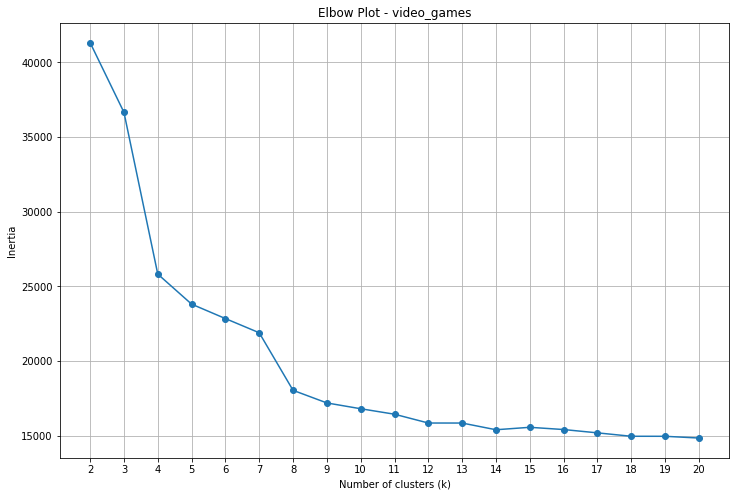


Performing KMeans clustering for category: video_games
Silhouette Score for video_games: 0.1758


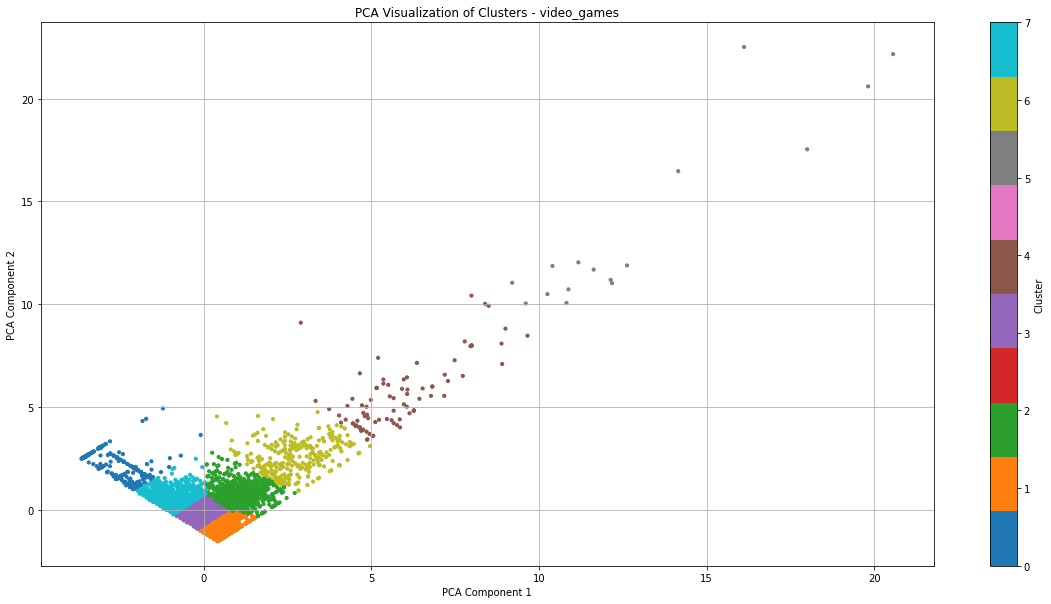

In [29]:
##############################################
###                                        ###
###               CLUSTERING               ###
###                                        ###
##############################################

from sklearn.cluster import KMeans
from kneed import KneeLocator
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Finding the optimal number of clusters for each category first

# we will use the elbow method to determine which number of
# clusters provides the optimal insertia value
# (sum of squares of distances from the center of the cluster)
K_range = list(range(2, 21))
optimal_k = {}
for category in categories:
    print(f"\nRunning Elbow Method for category: {category}")
    X = feature_matrices[category]
    inertia = []

    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(X)
        inertia.append(kmeans.inertia_)

    kneedle = KneeLocator(K_range, inertia, curve='convex', direction='decreasing')
    optimal_k[category] = kneedle.elbow
    print(f"Optimal number of clusters for {category}: {optimal_k[category]}")

    # plot for each category
    plt.figure(figsize=(12, 8))
    plt.xticks(K_range)
    plt.plot(K_range, inertia, marker='o')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Inertia')
    plt.title(f'Elbow Plot - {category}')
    plt.grid(True)
    plt.show()


silhouette_scores = {}

for category in categories:
    print(f"\nPerforming KMeans clustering for category: {category}")
    X = feature_matrices[category]
    k = optimal_k[category]

    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X)

    score = silhouette_score(X, cluster_labels)
    silhouette_scores[category] = score
    print(f"Silhouette Score for {category}: {score:.4f}")

    # plot 2D PCA visualization of clusters
    pca = PCA(n_components=2)
    X_dense = X.toarray() if hasattr(X, "toarray") else X
    X_reduced = pca.fit_transform(X_dense)

    plt.figure(figsize=(20, 10))
    scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=cluster_labels, cmap='tab10', s=10)
    plt.title(f"PCA Visualization of Clusters - {category}")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.colorbar(scatter, label='Cluster')
    plt.grid(True)
    plt.show()

#### Task 2: Recommendation System

In [10]:
##############################################################
###                                                        ###
###           ITEM-BASED COLLABORATIVE FILTERING           ###
###                                                        ###
##############################################################

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# at first, we need to create a matrix that contains user_id, asin, rating
user_item_matrices = {}
for category in categories:
    df = reviews_dfs[category][['user_id', 'parent_asin', 'rating']].dropna()
    user_item_matrices[category] = df.pivot_table(index='user_id', columns='parent_asin', values='rating').fillna(0)

    print(f"User-Item Matrix for {category}:")
    print(f"Shape: {user_item_matrices[category].shape}")

item_similarity_matrices = {}
print("")
for category in categories:
    matrix = user_item_matrices[category]
    # calculating similarity between products (item-based similarity)
    item_similarity = cosine_similarity(matrix.T)
    # mapping index to ASIN
    item_ids = matrix.columns
    item_similarity_matrices[category] = pd.DataFrame(item_similarity, index=item_ids, columns=item_ids)

    print(f"Item-Item Similarity Matrix for {category}:")
    print(item_similarity_matrices[category].shape)


User-Item Matrix for video_games:
Shape: (7577, 10373)

Item-Item Similarity Matrix for video_games:
(10373, 10373)


In [11]:
# recommending products to user
def recommend_items_item_based(user_id, category, top_n):
    if user_id not in user_item_matrices[category].index:
        print(f"User {user_id} hasn't interacted with the category '{category}'.\n")
        return
    user_ratings = user_item_matrices[category].loc[user_id]
    item_sim = item_similarity_matrices[category]

    # products rated by this user
    rated_items = user_ratings[user_ratings > 0].index.tolist()
    if not rated_items:
        print(f"User {user_id} has not rated any items in category {category}.\n")
        return

    # prediction scores
    scores = {}
    for item in rated_items:
        similarity_scores = item_sim[item]  # row with similarity values compared to all other products
        rating = user_ratings[item]

        for similar_item, sim_score in similarity_scores.items():
            if similar_item in rated_items:
                continue
            if sim_score <= 0:
                continue

            if similar_item not in scores:
                scores[similar_item] = 0.0
            scores[similar_item] += sim_score * rating

    # sorting predictions
    sorted_items = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    top_recommendations = [asin for asin, _ in sorted_items[:top_n]]
    # if for some reason the products rated by the user can't indicate other products for recommendation
    if not top_recommendations:
        print(f"No recommendations could be made for user {user_id} in category '{category}'.\n")
        return

    # map ASINs to titles using meta_dfs
    # and print results/recommendations
    meta_df = meta_dfs[category]
    print(f"Recommendations for user {user_id} in category '{category}':")
    print(f"aka: From {category}, you might also like:\n")
    for i, asin in enumerate(top_recommendations, start=1):
        title = meta_df.loc[meta_df['parent_asin'] == asin, 'title'].values
        if len(title)>0:
            print(f"{i}. {title[0]} (ASIN: {asin})")
        else:
            print(f"{i}. No title found (ASIN: {asin})")
    print("")


some_user_id = user_item_matrices["video_games"].index[0]
recommend_items_item_based(some_user_id, "video_games", 3)

# testing for recommendations in different categories
# for category in categories:
#     recommend_items(some_user_id, category, top_n=3)

Recommendations for user AE22BZ4I2434QRWLOQ52XURGWREA in category 'video_games':
aka: From video_games, you might also like:

1. MXGP2 - PlayStation 4 (ASIN: B01CQAGNSO)
2. No title found (ASIN: B074MMGR8F)
3. No title found (ASIN: B00BGA9X9W)



In [12]:
##############################################################
###                                                        ###
###           USER-BASED COLLABORATIVE FILTERING           ###
###                                                        ###
##############################################################

def get_top_k_neighbors(user_id, category, k=5):
    user_sim_matrix = user_similarity_matrices[category]
    
    # if the user exists
    if user_id not in user_sim_matrix.index:
        print(f"\nUser {user_id} not found in category '{category}'.")
        return []
    
    similarity_scores = user_sim_matrix.loc[user_id]
    # we don't need the specific user
    similarity_scores = similarity_scores.drop(user_id)
    # sorting based on descending similarity (top k of them)
    top_k_users = similarity_scores.sort_values(ascending=False).head(k).index.tolist()
    
    return top_k_users

user_similarity_matrices = {}

for category in categories:
    matrix = user_item_matrices[category]  # rows: users, columns: products
    similarity = cosine_similarity(matrix)  # similarity between users
    user_ids = matrix.index
    user_similarity_matrices[category] = pd.DataFrame(similarity, index=user_ids, columns=user_ids)
    
    print(f"User-User Similarity Matrix for '{category}':")
    print(user_similarity_matrices[category].shape)


some_user_id = user_item_matrices["video_games"].index[0]
neighbors = get_top_k_neighbors(some_user_id, "video_games", 3)
if neighbors:
    print(f"\nFor {some_user_id} the top similar users are:")
    print(neighbors)
else:
    print(f"No recommendations could be made for user {some_user_id}.\n")

User-User Similarity Matrix for 'video_games':
(7577, 7577)

For AE22BZ4I2434QRWLOQ52XURGWREA the top similar users are:
['AGB57S6VIS4N3XMMKGI5GMZ25YOA', 'AGF6SGAS4DS2URYWIJCAXSRIS2LQ', 'AE22CFXT3QZKUQJORVTGL3VQXAAA']


In [13]:
# recommending products to user

def recommend_items_user_based(user_id, category, top_n=5, k=5):
    if user_id not in user_item_matrices[category].index:
        print(f"User {user_id} hasn't interacted with the category '{category}'.\n")
        return []

    user_matrix = user_item_matrices[category]
    user_sim_matrix = user_similarity_matrices[category]
    neighbors = get_top_k_neighbors(user_id, category, k)
    if not neighbors:
        print(f"No similar users found for user {user_id} in category '{category}'.\n")
        return []

    # user's ratings
    user_ratings = user_matrix.loc[user_id]
    rated_items = user_ratings[user_ratings > 0].index

    if rated_items.empty:
        print(f"User {user_id} has not rated any items in category '{category}'.\n")
        return []

    # predicting rating for every product he hasn't seen
    scores = {}
    for neighbor in neighbors:
        similarity = user_sim_matrix.loc[user_id, neighbor]
        neighbor_ratings = user_matrix.loc[neighbor]

        for item, rating in neighbor_ratings.items():
            if item in rated_items or rating == 0:
                continue
            if item not in scores:
                scores[item] = [0.0, 0.0]
            # [sum(sim * rating), sum(sim)]
            scores[item][0] += similarity * rating
            scores[item][1] += similarity

    # final predicted rating for each item
    predicted_scores = {
        item: (score_sum / sim_sum)
        for item, (score_sum, sim_sum) in scores.items()
        if sim_sum > 0
    }

    if not predicted_scores:
        print(f"No recommendations could be made for user {user_id} in category '{category}'.\n")
        return []

    # keep the top_n items
    top_items = sorted(predicted_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]

    # also getting the titles from asins
    meta_df = meta_dfs[category]
    print(f"User-Based Recommendations for user {user_id} in category '{category}':")
    print(f"aka: From {category}, you might also like:\n")
    for i, (asin, score) in enumerate(top_items, start=1):
        title = meta_df.loc[meta_df['parent_asin'] == asin, 'title'].values
        title_str = title[0] if len(title) > 0 else "No title found"
        print(f"{i}. {title_str} (ASIN: {asin}) - Predicted rating: {score:.2f}")
    print("")

    return [asin for asin, _ in top_items]


some_user_id = user_item_matrices["video_games"].index[0]
for category in categories:
    recommend_items_user_based(some_user_id, category, 3)


User-Based Recommendations for user AE22BZ4I2434QRWLOQ52XURGWREA in category 'video_games':
aka: From video_games, you might also like:

1. MXGP2 - PlayStation 4 (ASIN: B01CQAGNSO) - Predicted rating: 5.00
2. No title found (ASIN: B00BGA9X9W) - Predicted rating: 5.00
3. No title found (ASIN: B074MMGR8F) - Predicted rating: 5.00



In [14]:
#####################################################
###                                               ###
###            CONTENT-BASED FILTERING            ###
###                                               ###
#####################################################

from gensim.models import KeyedVectors
from tqdm import tqdm

path = "./GoogleNews-vectors-negative300.bin/GoogleNews-vectors-negative300.bin"

print("Loading Word2Vec model...")
word2vec_model = KeyedVectors.load_word2vec_format(path, binary=True)
print("Model loaded successfully.")


def get_mean_vector(text, model):
    words = re.findall(r'\b\w+\b', str(text).lower())
    vectors = [model[word] for word in words if word in model]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size)  # fallback: zero vector

# dictionary to store content vectors (one per product description)
content_vectors = {}

for category in categories:
    print(f"Vectorizing descriptions for category: {category}...")
    descriptions = meta_dfs[category]['description']
    vectors = []
    
    for desc in tqdm(descriptions, desc=f"{category}"):
        vec = get_mean_vector(desc, word2vec_model)
        vectors.append(vec)
    
    content_vectors[category] = np.vstack(vectors)
    print(f"Vector shape for {category}: {content_vectors[category].shape}")


# creating content based similarity matrices
content_similarity_matrices = {}

for category in categories:
    print(f"Computing content similarity for: {category}")
    
    vectors = content_vectors[category]  # [num_of_products, 300]
    similarity = cosine_similarity(vectors)  # [num_of_products, num_of_products]
    
    asins = meta_dfs[category]['parent_asin'].values
    sim_df = pd.DataFrame(similarity, index=asins, columns=asins)
    
    content_similarity_matrices[category] = sim_df
    print(f"Similarity matrix shape for {category}: {sim_df.shape}")

Loading Word2Vec model...
Model loaded successfully.
Vectorizing descriptions for category: video_games...


video_games: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20001/20001 [00:04<00:00, 4780.42it/s]


Vector shape for video_games: (20001, 300)
Computing content similarity for: video_games
Similarity matrix shape for video_games: (20001, 20001)


In [16]:
# recommending products to user

def recommend_items_content_based(user_id, category, top_n=5):
    if user_id not in user_item_matrices[category].index:
        print(f"User {user_id} not found in category '{category}'.\n")
        return []
    
    user_ratings = user_item_matrices[category].loc[user_id]
    rated_items = user_ratings[user_ratings > 0].index.tolist()
    
    if not rated_items:
        print(f"User {user_id} has not rated any items in category '{category}'.\n")
        return []

    similarity_matrix = content_similarity_matrices[category]
    
    scores = {}
    for item in rated_items:
        if item not in similarity_matrix.index:
            continue
        similar_items = similarity_matrix[item]
        for other_item, score in similar_items.items():
            if other_item in rated_items or other_item == item:
                continue
            if other_item not in scores:
                scores[other_item] = 0.0
            scores[other_item] += score

    if not scores:
        print(f"No content-based recommendations found for user {user_id} in '{category}'.\n")
        return []

    # sort by score
    recommended_items = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    
    meta_df = meta_dfs[category]
    print(f"\nContent-Based Recommendations for user {user_id} in '{category}':\n")
    for i, (asin, score) in enumerate(recommended_items, start=1):
        title = meta_df.loc[meta_df['parent_asin'] == asin, 'title'].values
        title_str = title[0] if len(title) > 0 else "No title found"
        print(f"{i}. {title_str} (ASIN: {asin}) - Similarity score: {score:.3f}")
    
    return [asin for asin, _ in recommended_items]



some_user_id = user_item_matrices["video_games"].index[1]
recommend_items_content_based(some_user_id, "video_games", 5)


Content-Based Recommendations for user AE22CFXT3QZKUQJORVTGL3VQXAAA in 'video_games':

1. Technoskin - Hard carrying case for Nintendo Switch, White with Flowers (ASIN: B07D4KN9MW) - Similarity score: 2.248
2. Technoskin - Compact Travel Carrying Case for NEW 3DS or NEW 3DS XL - Black - 8 Game Holders - Hard Cover - Mesh Accessory Pouch - Carrying Strap (ASIN: B00PXLNYF4) - Similarity score: 2.223
3. Technoskin - All In One Travel Carrying Case for NEW 3DS or NEW 3DS XL - Black and Blue - 12 Game Holders - Charger Pouch - Carrying Strap (ASIN: B01G9ET8Z8) - Similarity score: 2.219
4. 2DS XL Case, Orzly Carry Case for New Nintendo 2DS XL - Protective Hard Shell Portable Travel Case Pouch for New 2DS XL Console with Slots for Games & Zip Pocket - Blue on Black (ASIN: B0742DRGJT) - Similarity score: 2.207
5. Full Body Silicon Case for Nintendo Switch - Orzly Stretch Grip Flexible Silicon Skin Full Body Cover Protective Case in Blue for use on Nintendo Switch Console in Handheld Gamepad M

['B07D4KN9MW', 'B00PXLNYF4', 'B01G9ET8Z8', 'B0742DRGJT', 'B06XKTKHG6']

In [ ]:
#################################################
###                                           ###
###              HYBRID APPROACH              ###
###                                           ###
#################################################


# we need to get the cf scores for the average calculation
def get_cf_scores(user_id, category, k=5):
    if user_id not in user_item_matrices[category].index:
        return {}

    user_matrix = user_item_matrices[category]
    user_sim_matrix = user_similarity_matrices[category]
    neighbors = get_top_k_neighbors(user_id, category, k)
    if not neighbors:
        return {}

    user_ratings = user_matrix.loc[user_id]
    rated_items = user_ratings[user_ratings > 0].index

    scores = {}
    for neighbor in neighbors:
        similarity = user_sim_matrix.loc[user_id, neighbor]
        neighbor_ratings = user_matrix.loc[neighbor]

        for item, rating in neighbor_ratings.items():
            if item in rated_items or rating == 0:
                continue
            if item not in scores:
                scores[item] = [0.0, 0.0]
            scores[item][0] += similarity * rating
            scores[item][1] += similarity

    predicted_scores = {
        item: (score_sum / sim_sum)
        for item, (score_sum, sim_sum) in scores.items()
        if sim_sum > 0
    }

    return predicted_scores


# we need to get the cbf scores for the average calculation
def get_cbf_scores(user_id, category):
    if user_id not in user_item_matrices[category].index:
        return {}

    user_ratings = user_item_matrices[category].loc[user_id]
    rated_items = user_ratings[user_ratings > 0].index.tolist()

    if not rated_items:
        return {}

    similarity_matrix = content_similarity_matrices[category]
    scores = {}

    for item in rated_items:
        if item not in similarity_matrix.index:
            continue
        similar_items = similarity_matrix[item]
        for other_item, score in similar_items.items():
            if other_item in rated_items or other_item == item:
                continue
            if other_item not in scores:
                scores[other_item] = 0.0
            scores[other_item] += score

    return scores

In [ ]:
# recommending products to user

def recommend_items_hybrid(user_id, category, top_n, cf_weight, cbf_weight):
    cf_scores = get_cf_scores(user_id, category)
    cbf_scores = get_cbf_scores(user_id, category)

    # searching for common products
    common_items = set(cf_scores.keys()) & set(cbf_scores.keys())
    if not common_items:
        print("No common products for comparison between CF and CBF.")
        return []

    hybrid_scores = {}
    for item in common_items:
        hybrid_scores[item] = (cf_scores[item] * cf_weight) + (cbf_scores[item] * cbf_weight)

    top_items = sorted(hybrid_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]

    meta_df = meta_dfs[category]
    print(f"\nHybrid Recommendations for user {user_id} in category '{category}':\n")
    for i, (asin, score) in enumerate(top_items, start=1):
        title = meta_df.loc[meta_df['parent_asin'] == asin, 'title'].values
        title_str = title[0] if len(title) > 0 else "No title found"
        print(f"{i}. {title_str} (ASIN: {asin}) - Hybrid Score: {score:.3f}")

    return [asin for asin, _ in top_items]



some_user_id = user_item_matrices["video_games"].index[6]
recommend_items_hybrid(some_user_id, "video_games", 5, 0.7, 0.3)


Hybrid Recommendations for user AE24KXPFYTDKJDKBXZVHJKUBGZYQ in category 'video_games':

1. DISNEY INFINITY Starter Pack 3DS (ASIN: B00BLDJ1T6) - Hybrid Score: 3.755


['B00BLDJ1T6']

In [26]:
# evaluating using recall@k

def recall_at_k(user_id, category, recommend_func, k=5, test_ratio=0.3):
    # calculates recall@k for the user: user_id
    # recommend_func: could be one of the three above (cf, cbf, hybrid)
    # test_ratio is the percentage of data that'll be used for testing
    if user_id not in user_item_matrices[category].index:
        print(f"User {user_id} not found in {category}.")
        return None

    user_ratings = user_item_matrices[category].loc[user_id]
    rated_items = user_ratings[user_ratings > 0].index.tolist()

    if len(rated_items) < 2:
        print(f"Not enough rated items to compute recall for user {user_id}.")
        return None

    import random
    random.shuffle(rated_items)

    split_index = int(len(rated_items) * (1 - test_ratio))
    train_items = set(rated_items[:split_index])
    test_items = set(rated_items[split_index:])

    if not test_items:
        print(f"No test items available for evaluation for user {user_id}.")
        return None

    # original user-item matrix
    original_matrix = user_item_matrices[category].copy()
    for item in test_items:
        user_item_matrices[category].at[user_id, item] = 0  # "hiding" the item

    try:
        recommended_items = recommend_func(user_id, category, k)
    except Exception as e:
        print(f"Error while running recommendation function: {e}")
        return None

    # restoring user-item matrix
    user_item_matrices[category] = original_matrix

    if not recommended_items:
        return 0.0

    hits = set(recommended_items) & test_items
    recall = len(hits) / len(test_items)
    return recall

some_user_id = user_item_matrices["video_games"].index[1]
# user based CF
recall_cf = recall_at_k(some_user_id, "video_games", recommend_items_user_based, k=5)
if recall_cf is not None:
    print(f"Recall@5 (User-based CF): {recall_cf:.3f}")
else:
    print("Recall@5 (User-based CF): not enough data")

# CBF
recall_cbf = recall_at_k(some_user_id, "video_games", recommend_items_content_based, k=5)
if recall_cbf is not None:
    print(f"Recall@5 (CBF): {recall_cbf:.3f}")
else:
    print("Recall@5 (CBF): not enough data")

# hybrid
recall_hybrid = recall_at_k(
    some_user_id,
    "video_games",
    lambda u, c, k: recommend_items_hybrid(u, c, k, 0.7, 0.3),
    k=5
)
if recall_hybrid is not None:
    print(f"Recall@5 (Hybrid): {recall_hybrid:.3f}")
else:
    print("Recall@5 (Hybrid): not enough data")

User-Based Recommendations for user AE22CFXT3QZKUQJORVTGL3VQXAAA in category 'video_games':
aka: From video_games, you might also like:

1. BENGOO Stereo Pro Gaming Headset for PS4, PC, Xbox One Controller, Noise Cancelling Over Ear Headphones with Mic, LED Light, Bass Surround, Soft Memory Earmuffs for Laptop Mac Wii Accessory Kits (ASIN: B0BN942894) - Predicted rating: 4.60

Recall@5 (User-based CF): 0.200

Content-Based Recommendations for user AE22CFXT3QZKUQJORVTGL3VQXAAA in 'video_games':

1. Technoskin - All In One Travel Carrying Case for NEW 3DS or NEW 3DS XL - Black and Blue - 12 Game Holders - Charger Pouch - Carrying Strap (ASIN: B01G9ET8Z8) - Similarity score: 1.000
2. Technoskin - Hard carrying case for Nintendo Switch, White with Flowers (ASIN: B07D4KN9MW) - Similarity score: 0.956
3. Technoskin - Compact Travel Carrying Case for NEW 3DS or NEW 3DS XL - Black - 8 Game Holders - Hard Cover - Mesh Accessory Pouch - Carrying Strap (ASIN: B00PXLNYF4) - Similarity score: 0.955

In [28]:
# evaluating results of the three methods based on the 10 first users

video_games_users = user_item_matrices["video_games"].index[:10]

results = []

for user_id in video_games_users:
    print(f"Evaluating user: {user_id}")

    rec_cf = recall_at_k(user_id, "video_games", recommend_items_user_based, k=5)
    rec_cbf = recall_at_k(user_id, "video_games", recommend_items_content_based, k=5)
    rec_hybrid = recall_at_k(
        user_id,
        "video_games",
        lambda u, c, k: recommend_items_hybrid(u, c, k, 0.7, 0.3),
        k=5
    )

    results.append({
        "user_id": user_id,
        "CF": round(rec_cf, 3) if rec_cf is not None else None,
        "CBF": round(rec_cbf, 3) if rec_cbf is not None else None,
        "Hybrid": round(rec_hybrid, 3) if rec_hybrid is not None else None
    })

# creating and displaying dataframe
df_results = pd.DataFrame(results)
print("\n===== Recall@5 Table =====")
print(df_results)

# average per method
print("\n===== Average values Recall@5 =====")
print(df_results[['CF', 'CBF', 'Hybrid']].mean())


Evaluating user: AE22BZ4I2434QRWLOQ52XURGWREA
Not enough rated items to compute recall for user AE22BZ4I2434QRWLOQ52XURGWREA.
Not enough rated items to compute recall for user AE22BZ4I2434QRWLOQ52XURGWREA.
Not enough rated items to compute recall for user AE22BZ4I2434QRWLOQ52XURGWREA.
Evaluating user: AE22CFXT3QZKUQJORVTGL3VQXAAA
No recommendations could be made for user AE22CFXT3QZKUQJORVTGL3VQXAAA in category 'video_games'.


Content-Based Recommendations for user AE22CFXT3QZKUQJORVTGL3VQXAAA in 'video_games':

1. Nyko Extend Link for Kinect - Xbox 360 (ASIN: B004UPPBG4) - Similarity score: 1.371
2. Technoskin - Hard carrying case for Nintendo Switch, White with Flowers (ASIN: B07D4KN9MW) - Similarity score: 1.322
3. Full Body Silicon Case for Nintendo Switch - Orzly Stretch Grip Flexible Silicon Skin Full Body Cover Protective Case in Blue for use on Nintendo Switch Console in Handheld Gamepad Mode (ASIN: B06XKTKHG6) - Similarity score: 1.314
4. Oritys Strap for Oculus Quest/Oculus 